In [ ]:
!pip install torch pandas numpy matplotlib scikit-learn pyarrow umap-learn -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Confirm GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/PRISM'
PATHS = {
    'features' : f'{BASE_PATH}/features',
    'splits'   : f'{BASE_PATH}/splits',
    'results'  : f'{BASE_PATH}/results',
    'models'   : f'{BASE_PATH}/models',
    'plots'    : f'{BASE_PATH}/plots',
    'raw'      : f'{BASE_PATH}/raw'
}

for path in PATHS.values():
    os.makedirs(path, exist_ok=True)

print("Drive mounted and paths ready")

Mounted at /content/drive
Drive mounted and paths ready


In [ ]:
CONFIG = {
    'window'      : 30,       # lookback window in days
    'latent_dim'  : 32,       # size of latent vector
    'hidden_dim'  : 128,      # LSTM hidden units
    'num_layers'  : 2,        # LSTM layers
    'batch_size'  : 64,
    'epochs'      : 100,
    'lr'          : 1e-3,
    'dropout'     : 0.2,
    'patience'    : 10        # early stopping patience
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k:<15}: {v}")

Configuration:
  window         : 30
  latent_dim     : 32
  hidden_dim     : 128
  num_layers     : 2
  batch_size     : 64
  epochs         : 100
  lr             : 0.001
  dropout        : 0.2
  patience       : 10


In [ ]:
print("Loading features...")

features = pd.read_parquet(f"{PATHS['features']}/features.parquet")

# Drop SPY columns — agent allocates across sector ETFs only
# SPY is market benchmark, not an allocatable asset
spy_cols = [col for col in features.columns if col.startswith('SPY')]
features = features.drop(columns=spy_cols)

print(f"Feature matrix shape : {features.shape}")
print(f"Date range           : {features.index[0].date()} to {features.index[-1].date()}")
print(f"Features per day     : {features.shape[1]}")
print(f"\nFeature columns:")
print(list(features.columns))

# Scale features
scaler = StandardScaler()

train_data = features['2008':'2017']
X_scaled   = scaler.fit_transform(train_data.values)
X_full     = scaler.transform(features.values)

joblib.dump(scaler, f"{PATHS['models']}/lstm_scaler.pkl")

print(f"\nTraining data shape  : {train_data.shape}")
print(f"Scaled range         : [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
print(f"Scaler saved")

Loading features...
Feature matrix shape : (3967, 56)
Date range           : 2008-03-31 to 2023-12-29
Features per day     : 56

Feature columns:
['XLK_return', 'XLK_vol20', 'XLK_vol60', 'XLK_mom20', 'XLK_mom60', 'XLK_volratio', 'XLK_spycorr', 'XLE_return', 'XLE_vol20', 'XLE_vol60', 'XLE_mom20', 'XLE_mom60', 'XLE_volratio', 'XLE_spycorr', 'XLV_return', 'XLV_vol20', 'XLV_vol60', 'XLV_mom20', 'XLV_mom60', 'XLV_volratio', 'XLV_spycorr', 'XLF_return', 'XLF_vol20', 'XLF_vol60', 'XLF_mom20', 'XLF_mom60', 'XLF_volratio', 'XLF_spycorr', 'XLU_return', 'XLU_vol20', 'XLU_vol60', 'XLU_mom20', 'XLU_mom60', 'XLU_volratio', 'XLU_spycorr', 'XLI_return', 'XLI_vol20', 'XLI_vol60', 'XLI_mom20', 'XLI_mom60', 'XLI_volratio', 'XLI_spycorr', 'XLP_return', 'XLP_vol20', 'XLP_vol60', 'XLP_mom20', 'XLP_mom60', 'XLP_volratio', 'XLP_spycorr', 'XLY_return', 'XLY_vol20', 'XLY_vol60', 'XLY_mom20', 'XLY_mom60', 'XLY_volratio', 'XLY_spycorr']

Training data shape  : (2458, 56)
Scaled range         : [-9.479, 11.107]
Sc

In [ ]:
class WindowDataset(Dataset):
    def __init__(self, data, window):
        self.data   = torch.FloatTensor(data)
        self.window = window

    def __len__(self):
        return len(self.data) - self.window

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]
        return x, x  # autoencoder: input = target

train_dataset = WindowDataset(X_scaled, CONFIG['window'])
train_loader  = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0
)

print(f"Dataset size    : {len(train_dataset)} windows")
print(f"Window shape    : ({CONFIG['window']}, {features.shape[1]})")
print(f"Batches per epoch: {len(train_loader)}")

# Quick sanity check
sample_x, sample_y = next(iter(train_loader))
print(f"Batch input shape: {sample_x.shape}")
print(f"Batch target shape: {sample_y.shape}")

Dataset size    : 2428 windows
Window shape    : (30, 56)
Batches per epoch: 38
Batch input shape: torch.Size([64, 30, 56])
Batch target shape: torch.Size([64, 30, 56])


In [ ]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers, dropout):
        super(LSTMEncoder, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        # Take last layer hidden state
        last_hidden = hidden[-1]
        latent = self.relu(self.fc(last_hidden))
        return latent


class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, seq_len, num_layers, dropout):
        super(LSTMDecoder, self).__init__()
        self.seq_len = seq_len
        self.fc      = nn.Linear(latent_dim, hidden_dim)
        self.relu    = nn.ReLU()
        self.lstm    = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.output_fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, latent):
        x = self.relu(self.fc(latent))
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm(x)
        x = self.output_fc(x)
        return x


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, seq_len, num_layers, dropout):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = LSTMEncoder(input_dim, hidden_dim, latent_dim, num_layers, dropout)
        self.decoder = LSTMDecoder(latent_dim, hidden_dim, input_dim, seq_len, num_layers, dropout)

    def forward(self, x):
        latent = self.encoder(x)
        recon  = self.decoder(latent)
        return recon, latent


# Instantiate model
input_dim = features.shape[1]

model = LSTMAutoencoder(
    input_dim  = input_dim,
    hidden_dim = CONFIG['hidden_dim'],
    latent_dim = CONFIG['latent_dim'],
    seq_len    = CONFIG['window'],
    num_layers = CONFIG['num_layers'],
    dropout    = CONFIG['dropout']
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

Model architecture:
LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(56, 128, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=128, out_features=32, bias=True)
    (relu): ReLU()
  )
  (decoder): LSTMDecoder(
    (fc): Linear(in_features=32, out_features=128, bias=True)
    (relu): ReLU()
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
    (output_fc): Linear(in_features=128, out_features=56, bias=True)
  )
)

Total trainable parameters: 507,096


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

train_losses = []
best_loss    = np.inf
patience_ctr = 0
best_weights = None

print(f"Training LSTM Autoencoder for {CONFIG['epochs']} epochs...\n")

for epoch in range(CONFIG['epochs']):
    model.train()
    epoch_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        recon, latent = model(batch_x)
        loss = criterion(recon, batch_y)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    # Early stopping
    if avg_loss < best_loss:
        best_loss    = avg_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | Loss: {avg_loss:.6f} | Best: {best_loss:.6f} | Patience: {patience_ctr}/{CONFIG['patience']}")

    if patience_ctr >= CONFIG['patience']:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Restore best weights
model.load_state_dict(best_weights)
print(f"\nTraining complete. Best loss: {best_loss:.6f}")

Training LSTM Autoencoder for 100 epochs...

Epoch  10/100 | Loss: 0.492807 | Best: 0.492807 | Patience: 0/10
Epoch  20/100 | Loss: 0.390128 | Best: 0.390128 | Patience: 0/10
Epoch  30/100 | Loss: 0.340998 | Best: 0.340998 | Patience: 0/10
Epoch  40/100 | Loss: 0.309841 | Best: 0.309841 | Patience: 0/10
Epoch  50/100 | Loss: 0.303158 | Best: 0.300792 | Patience: 4/10
Epoch  60/100 | Loss: 0.283030 | Best: 0.282739 | Patience: 1/10
Epoch  70/100 | Loss: 0.274605 | Best: 0.273728 | Patience: 3/10
Epoch  80/100 | Loss: 0.267400 | Best: 0.264940 | Patience: 2/10
Epoch  90/100 | Loss: 0.260697 | Best: 0.258823 | Patience: 2/10
Epoch 100/100 | Loss: 0.252368 | Best: 0.252368 | Patience: 0/10

Training complete. Best loss: 0.252368


In [ ]:
torch.save(model.state_dict(), f"{PATHS['models']}/lstm_autoencoder.pt")
torch.save({
    'model_state_dict' : model.state_dict(),
    'config'           : CONFIG,
    'input_dim'        : input_dim,
    'feature_columns'  : list(features.columns)
}, f"{PATHS['models']}/lstm_checkpoint.pt")

print(f"Model saved to Drive")
print(f"  lstm_autoencoder.pt")
print(f"  lstm_checkpoint.pt")

Model saved to Drive
  lstm_autoencoder.pt
  lstm_checkpoint.pt


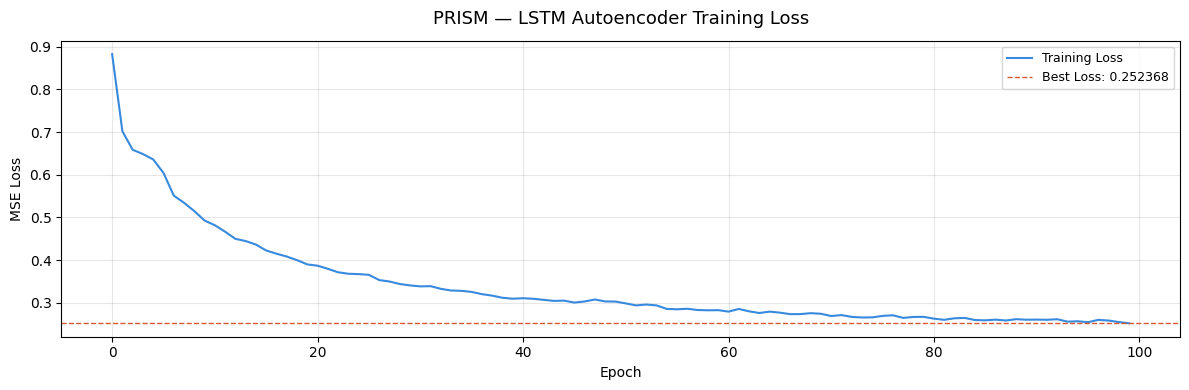

Training loss plot saved


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(train_losses, color='#378ADD', linewidth=1.5, label='Training Loss')
ax.axhline(best_loss, color='#D85A30', linewidth=1,
           linestyle='--', label=f'Best Loss: {best_loss:.6f}')
ax.set_title('PRISM — LSTM Autoencoder Training Loss',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/10_lstm_training_loss.png", dpi=150)
plt.show()
print("Training loss plot saved")

In [ ]:
print("Extracting latent vectors for full dataset...")

model.eval()

full_dataset = WindowDataset(X_full, CONFIG['window'])
full_loader  = DataLoader(full_dataset, batch_size=256, shuffle=False)

latent_vectors = []

with torch.no_grad():
    for batch_x, _ in full_loader:
        batch_x = batch_x.to(device)
        _, latent = model(batch_x)
        latent_vectors.append(latent.cpu().numpy())

latent_array = np.vstack(latent_vectors)

# Align index — windowing removes first (window-1) days
latent_index = features.index[CONFIG['window']:]
latent_df    = pd.DataFrame(
    latent_array,
    index=latent_index,
    columns=[f'latent_{i}' for i in range(CONFIG['latent_dim'])]
)

latent_df.to_parquet(f"{PATHS['results']}/lstm_latents.parquet")

print(f"Latent vectors shape : {latent_df.shape}")
print(f"Date range           : {latent_df.index[0].date()} to {latent_df.index[-1].date()}")
print(f"\nFirst 3 rows (first 8 dimensions):")
print(latent_df.iloc[:3, :8].round(4))
print(f"\nSaved to Drive")

Extracting latent vectors for full dataset...
Latent vectors shape : (3937, 32)
Date range           : 2008-05-12 to 2023-12-29

First 3 rows (first 8 dimensions):
            latent_0  latent_1  latent_2  latent_3  latent_4  latent_5  \
Date                                                                     
2008-05-12       0.0    0.0503    0.5051    1.2653    1.0142    1.8210   
2008-05-13       0.0    0.0144    0.5252    1.3110    0.9652    1.8300   
2008-05-14       0.0    0.0050    0.5078    1.3743    0.9686    1.8122   

            latent_6  latent_7  
Date                            
2008-05-12       0.0    0.8786  
2008-05-13       0.0    0.7943  
2008-05-14       0.0    0.7764  

Saved to Drive


Validating latent representation with PCA...



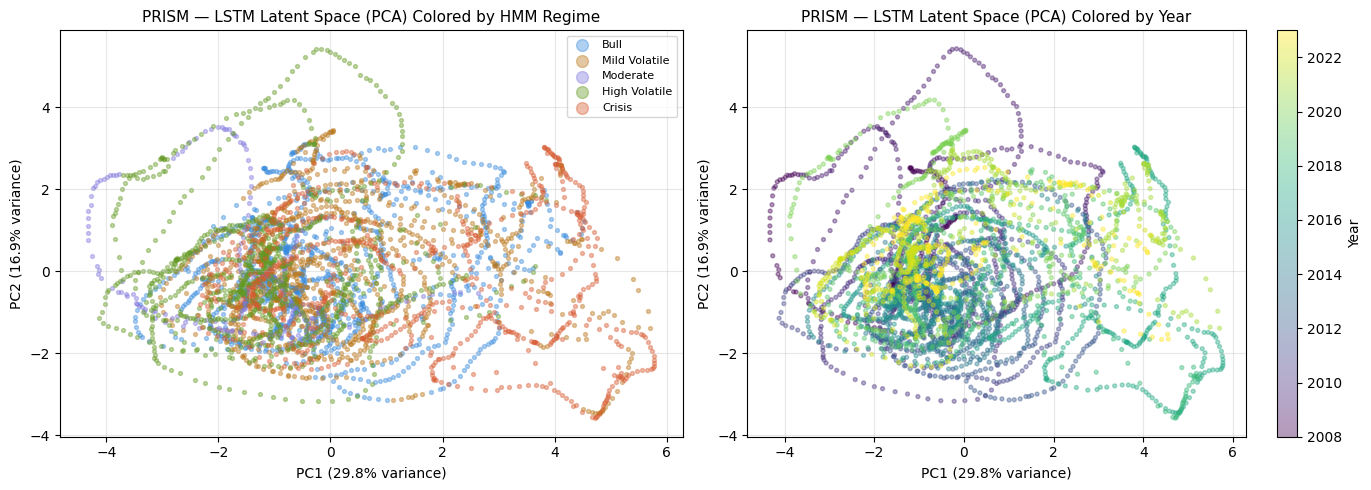

PCA explained variance: PC1=29.8%, PC2=16.9%
Total explained       : 46.6%


In [ ]:
print("Validating latent representation with PCA...\n")

# Load regime labels for coloring
regime_labels = pd.read_parquet(f"{PATHS['results']}/regime_labels.parquet")

# Align indices
common_idx    = latent_df.index.intersection(regime_labels.index)
latent_aligned = latent_df.loc[common_idx]
labels_aligned = regime_labels.loc[common_idx, 'regime_label']

# PCA
pca     = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_aligned.values)

regime_names  = ['Bull', 'Mild Volatile', 'Moderate', 'High Volatile', 'Crisis']
regime_colors = ['#378ADD', '#BA7517', '#7F77DD', '#639922', '#D85A30']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA colored by regime
for i, (name, color) in enumerate(zip(regime_names, regime_colors)):
    mask = labels_aligned == i
    if mask.sum() > 0:
        axes[0].scatter(
            latent_2d[mask, 0], latent_2d[mask, 1],
            c=color, label=name, alpha=0.4, s=8
        )

axes[0].set_title('PRISM — LSTM Latent Space (PCA) Colored by HMM Regime',
                  fontsize=11, fontweight='500')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend(fontsize=8, markerscale=3)
axes[0].grid(True, alpha=0.3)

# Right: PCA colored by year
years = pd.DatetimeIndex(common_idx).year
scatter = axes[1].scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=years, cmap='viridis', alpha=0.4, s=8
)
plt.colorbar(scatter, ax=axes[1], label='Year')
axes[1].set_title('PRISM — LSTM Latent Space (PCA) Colored by Year',
                  fontsize=11, fontweight='500')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/11_lstm_pca.png", dpi=150)
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total explained       : {sum(pca.explained_variance_ratio_[:2]):.1%}")

Checking reconstruction quality...



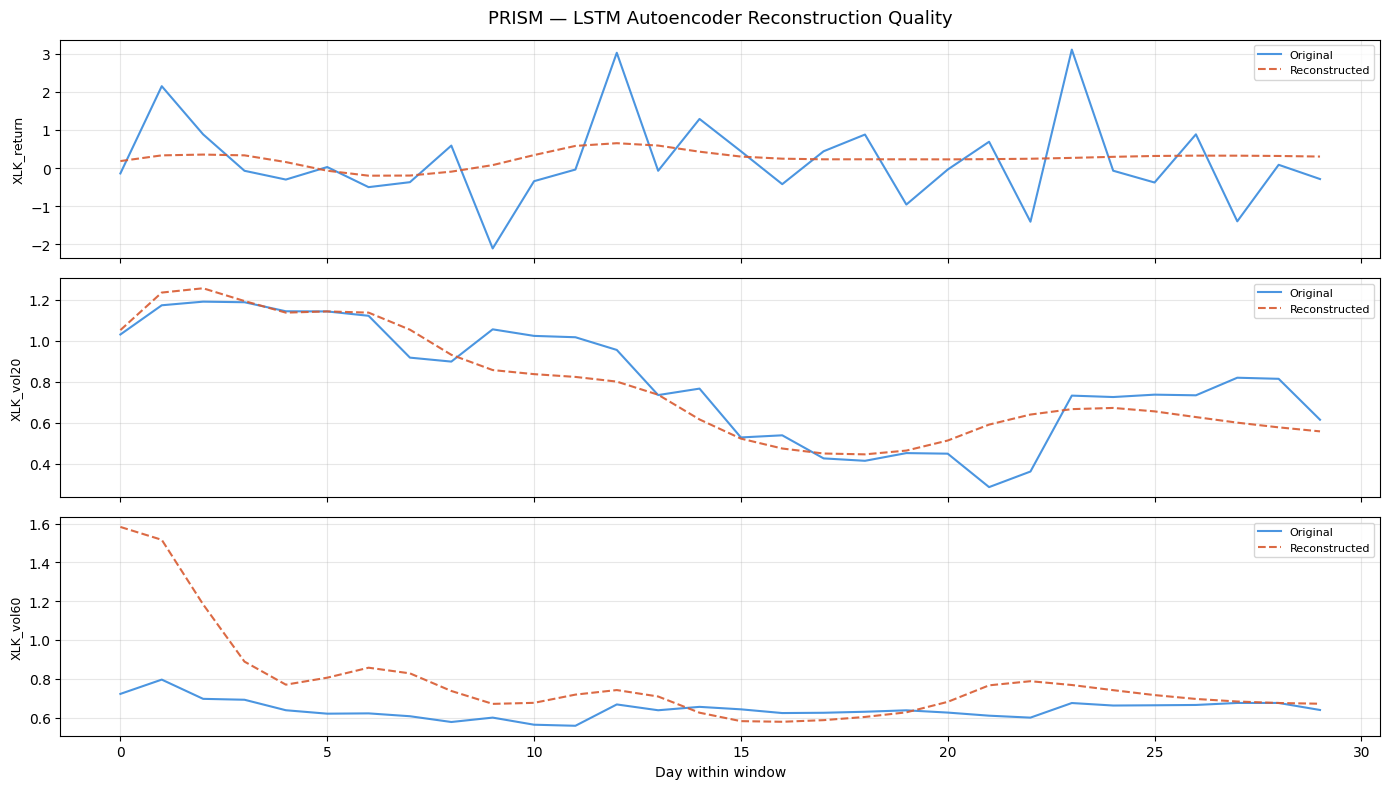

Sample reconstruction MSE: 0.284112
Good reconstruction: MSE should be close to training best loss (0.252368)


In [ ]:
print("Checking reconstruction quality...\n")

model.eval()

# Take a sample batch
sample_loader = DataLoader(
    WindowDataset(X_full, CONFIG['window']),
    batch_size=64, shuffle=False
)

sample_batch, _ = next(iter(sample_loader))
sample_batch    = sample_batch.to(device)

with torch.no_grad():
    recon, _ = model(sample_batch)

original = sample_batch.cpu().numpy()
reconstructed = recon.cpu().numpy()

# Plot reconstruction for first 3 features
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
feature_names = list(features.columns)[:3]

for i, (ax, fname) in enumerate(zip(axes, feature_names)):
    ax.plot(original[0, :, i],
            color='#378ADD', linewidth=1.5, label='Original', alpha=0.9)
    ax.plot(reconstructed[0, :, i],
            color='#D85A30', linewidth=1.5, label='Reconstructed',
            linestyle='--', alpha=0.9)
    ax.set_ylabel(fname, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title('PRISM — LSTM Autoencoder Reconstruction Quality',
                  fontsize=13, fontweight='500', pad=12)
axes[-1].set_xlabel('Day within window')

plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/12_lstm_reconstruction.png", dpi=150)
plt.show()

mse = np.mean((original - reconstructed) ** 2)
print(f"Sample reconstruction MSE: {mse:.6f}")
print(f"Good reconstruction: MSE should be close to training best loss ({best_loss:.6f})")

In [ ]:
print("Building combined state vector...\n")

regime_probs = pd.read_parquet(f"{PATHS['results']}/regime_probs.parquet")

# Align all three components on common dates
common_idx = latent_df.index\
    .intersection(regime_probs.index)\
    .intersection(features.index)

latent_aligned  = latent_df.loc[common_idx]
regime_aligned  = regime_probs.loc[common_idx]
features_aligned = features.loc[common_idx]

# Concatenate into full state vector
state_vector = pd.concat([
    features_aligned,
    latent_aligned,
    regime_aligned
], axis=1)

state_vector.to_parquet(f"{PATHS['results']}/state_vector.parquet")

print(f"Component dimensions:")
print(f"  Financial features : {features_aligned.shape[1]}")
print(f"  LSTM latent        : {latent_aligned.shape[1]}")
print(f"  HMM regime probs   : {regime_aligned.shape[1]}")
print(f"  Total state dim    : {state_vector.shape[1]}")
print(f"\nState vector shape   : {state_vector.shape}")
print(f"Date range           : {state_vector.index[0].date()} to {state_vector.index[-1].date()}")
print(f"\nState vector saved to Drive")

Building combined state vector...

Component dimensions:
  Financial features : 56
  LSTM latent        : 32
  HMM regime probs   : 5
  Total state dim    : 93

State vector shape   : (3937, 93)
Date range           : 2008-05-12 to 2023-12-29

State vector saved to Drive


In [ ]:
print("=" * 55)
print("   PRISM — LSTM ENCODER COMPLETE")
print("=" * 55)
print(f"\nArchitecture:")
print(f"  Input dim      : {input_dim} features")
print(f"  Window size    : {CONFIG['window']} days")
print(f"  Hidden dim     : {CONFIG['hidden_dim']}")
print(f"  Latent dim     : {CONFIG['latent_dim']}")
print(f"  Layers         : {CONFIG['num_layers']}")
print(f"\nTraining:")
print(f"  Best MSE loss  : {best_loss:.6f}")
print(f"  Device used    : {device}")
print(f"\nState vector:")
print(f"  Financial      : {features_aligned.shape[1]} dims")
print(f"  LSTM latent    : {latent_aligned.shape[1]} dims")
print(f"  HMM regimes    : {regime_aligned.shape[1]} dims")
print(f"  Total          : {state_vector.shape[1]} dims")
print(f"\nFiles saved:")
print(f"  models/lstm_autoencoder.pt")
print(f"  models/lstm_checkpoint.pt")
print(f"  models/lstm_scaler.pkl")
print(f"  results/lstm_latents.parquet")
print(f"  results/state_vector.parquet")
print(f"  plots/10_lstm_training_loss.png")
print(f"  plots/11_lstm_pca.png")
print(f"  plots/12_lstm_reconstruction.png")
print("=" * 55)
print("\nLSTM complete. Ready for SAC agent.")

   PRISM — LSTM ENCODER COMPLETE

Architecture:
  Input dim      : 56 features
  Window size    : 30 days
  Hidden dim     : 128
  Latent dim     : 32
  Layers         : 2

Training:
  Best MSE loss  : 0.252368
  Device used    : cuda

State vector:
  Financial      : 56 dims
  LSTM latent    : 32 dims
  HMM regimes    : 5 dims
  Total          : 93 dims

Files saved:
  models/lstm_autoencoder.pt
  models/lstm_checkpoint.pt
  models/lstm_scaler.pkl
  results/lstm_latents.parquet
  results/state_vector.parquet
  plots/10_lstm_training_loss.png
  plots/11_lstm_pca.png
  plots/12_lstm_reconstruction.png

LSTM complete. Ready for SAC agent.


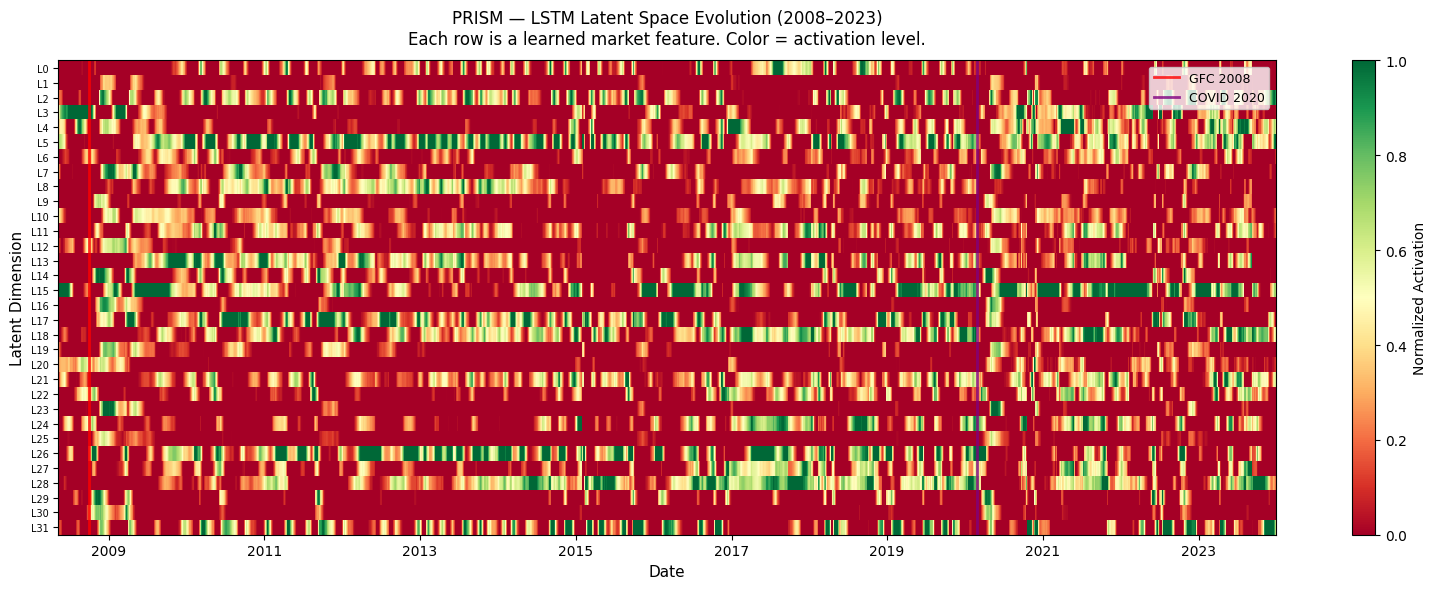

In [ ]:
latent_df = pd.read_parquet('/content/drive/MyDrive/PRISM/results/lstm_latents.parquet')

fig, ax = plt.subplots(figsize=(16, 6))

# Normalize for visualization
from sklearn.preprocessing import MinMaxScaler
viz_scaler = MinMaxScaler()
latent_norm = viz_scaler.fit_transform(latent_df.values.T)

im = ax.imshow(latent_norm, aspect='auto', cmap='RdYlGn',
               interpolation='nearest')

# Mark known events on x axis
dates = latent_df.index
gfc_idx   = dates.get_indexer([pd.Timestamp('2008-10-01')], method='nearest')[0]
covid_idx = dates.get_indexer([pd.Timestamp('2020-03-01')], method='nearest')[0]

ax.axvline(gfc_idx,   color='red',    linewidth=2, label='GFC 2008',    alpha=0.8)
ax.axvline(covid_idx, color='purple', linewidth=2, label='COVID 2020',  alpha=0.8)

# X axis labels
tick_positions = [dates.get_indexer([pd.Timestamp(f'{y}-01-01')],
                  method='nearest')[0] for y in range(2009, 2024, 2)]
tick_labels = [str(y) for y in range(2009, 2024, 2)]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_yticks(range(32))
ax.set_yticklabels([f'L{i}' for i in range(32)], fontsize=7)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Latent Dimension', fontsize=11)
ax.set_title('PRISM — LSTM Latent Space Evolution (2008–2023)\n'
             'Each row is a learned market feature. Color = activation level.',
             fontsize=12, fontweight='500', pad=12)
ax.legend(loc='upper right', fontsize=9)
plt.colorbar(im, ax=ax, label='Normalized Activation')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PRISM/plots/13_latent_heatmap.png', dpi=150)
plt.show()

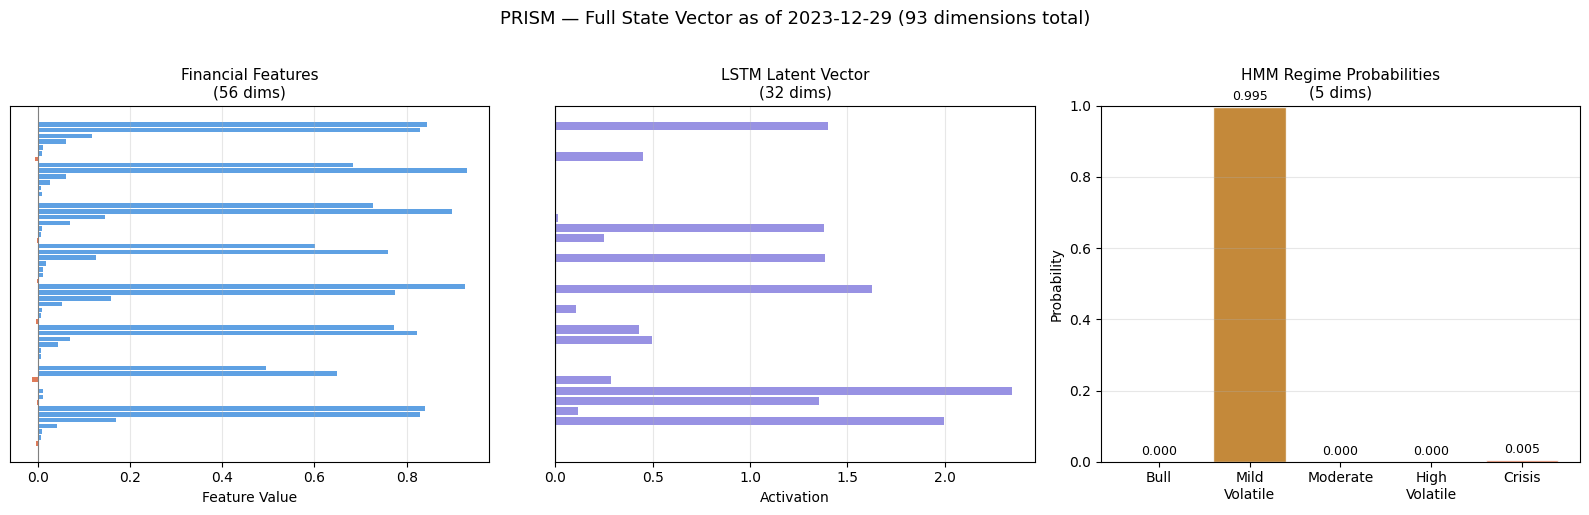

In [ ]:
state_vector = pd.read_parquet('/content/drive/MyDrive/PRISM/results/state_vector.parquet')
latest_state = state_vector.iloc[-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Financial features
fin_vals = latest_state[:56].values
axes[0].barh(range(len(fin_vals)), fin_vals,
             color=['#378ADD' if v >= 0 else '#D85A30' for v in fin_vals],
             alpha=0.8)
axes[0].set_title('Financial Features\n(56 dims)', fontsize=11, fontweight='500')
axes[0].set_xlabel('Feature Value')
axes[0].set_yticks([])
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: LSTM latent
lat_vals = latest_state[56:88].values
axes[1].barh(range(len(lat_vals)), lat_vals,
             color=['#7F77DD' if v >= 0 else '#BA7517' for v in lat_vals],
             alpha=0.8)
axes[1].set_title('LSTM Latent Vector\n(32 dims)', fontsize=11, fontweight='500')
axes[1].set_xlabel('Activation')
axes[1].set_yticks([])
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

# Panel 3: HMM regime probs
regime_names = ['Bull', 'Mild\nVolatile', 'Moderate', 'High\nVolatile', 'Crisis']
regime_colors = ['#378ADD', '#BA7517', '#7F77DD', '#639922', '#D85A30']
reg_vals = latest_state[88:].values
bars = axes[2].bar(regime_names, reg_vals,
                   color=regime_colors, alpha=0.85, edgecolor='white')
axes[2].set_title('HMM Regime Probabilities\n(5 dims)', fontsize=11, fontweight='500')
axes[2].set_ylabel('Probability')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, reg_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=9)

fig.suptitle(f'PRISM — Full State Vector as of {state_vector.index[-1].date()} '
             f'(93 dimensions total)',
             fontsize=13, fontweight='500', y=1.02)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PRISM/plots/14_state_vector_snapshot.png',
            dpi=150, bbox_inches='tight')
plt.show()